In [18]:
import numpy as np 
import matplotlib.pyplot as plt 
import h5py as h5
import sys
import glob
import seaborn as sns

#if necessary adjust the path from where to load stuff, but they should mostly live in the same dir:
sys.path.append("lib")
sys.path.append("../make_plots/")

import plot_utils

from POCAMSiPMHandler import breakdown_func, baseline, ampl

from pcm_monitoring_func import decode_value, get_timestamps, getADCreadings, extract_per_pwm, convert_to_perTrig, get_SiPM_dt



In [19]:
sns.set_palette('colorblind')

In [20]:
hem = '03'
pocam = '002'

batch = 'batch2'

T= 0

f_ = h5.File(f"/home/ecp/disk1/pocam_data/{batch}/prod_characterization_{hem}/Self_Monitoring_data_{T}C.h5")

In [21]:
all_data = {}
for sipm_pwm_ in f_['metadata/sipm_pwm']:
    all_data[sipm_pwm_]= {}
    for flm_ in f_['metadata']['flasher_modes']:
        all_data[sipm_pwm_][flm_.decode()] = extract_per_pwm(f_['flashes/{:d}/{:s}'.format(sipm_pwm_, flm_.decode())])

In [22]:
data_dict = {}


for flasher in ['lmg0', 'lmg1', 'lmg2', 'lmg3', 'kapu0', 'kapu3']:
    data_dict[flasher] = {}
    data_dict[flasher]["sipm_data"] = {}
    data_dict[flasher]["pd_data"] = {}
    
    lmg1_app = '_A'
    
    for sipm_pwm_ in f_['metadata']['sipm_pwm'][()]:#[:2]: 
        if not 'lmg1' in flasher:
            flasher_pd = flasher
        elif 'lmg1' in flasher:
            flasher_pd = flasher + lmg1_app#flasher_pd
        
        
        plotval = np.array([(all_data[sipm_pwm_][flasher_pd][fpwm_]['adcA']['sum'].mean() - all_data[sipm_pwm_][flasher_pd][0]['adcA']['sum'].mean()) for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        data_dict[flasher]["pd_data"]['adcA'] = {}
        data_dict[flasher]["pd_data"]['adcA']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["pd_data"]['adcA']['adcA_peak_mean'] = plotval
        data_dict[flasher]["pd_data"]['adcA']['adcA_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcA']['peak'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        plotval = np.array([(all_data[sipm_pwm_][flasher_pd][fpwm_]['adcB']['sum'].mean() - all_data[sipm_pwm_][flasher_pd][0]['adcB']['sum'].mean()) for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        
        data_dict[flasher]["pd_data"]['adcB'] = {}
        data_dict[flasher]["pd_data"]['adcB']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["pd_data"]['adcB']['adcB_peak_mean'] = plotval
        data_dict[flasher]["pd_data"]['adcB']['adcB_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['adcB']['peak'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )

        plotval = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['tdc2_dt'].mean() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
        data_dict[flasher]["sipm_data"]['tdc2'] = {}
        data_dict[flasher]["sipm_data"]['tdc2']['flasher_pwm'] = f_['metadata']['flasher_pwm'][()]
        data_dict[flasher]["sipm_data"]['tdc2']['tdc2_peak_mean'] = plotval
        data_dict[flasher]["sipm_data"]['tdc2']['tdc2_peak_std'] = np.array([all_data[sipm_pwm_][flasher_pd][fpwm_]['tdc2_dt'].std() for fpwm_ in f_['metadata']['flasher_pwm'][()] ] )
    

In [23]:
filepath = f'../output/batch2/pocam_{pocam}/hem_{hem}/LMG405/photons_*_-40C_1-20.json'

filelist = glob.glob(filepath)


In [24]:
filelist

['../output/batch2/pocam_002/hem_03/LMG405/photons_45000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_54000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_10000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_30000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_20000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_25000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_7500_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_35000_-40C_1-20.json',
 '../output/batch2/pocam_002/hem_03/LMG405/photons_15000_-40C_1-20.json']

In [25]:
import json

In [26]:
pwm = []
val_pd = []
val_pmt = []
for file in filelist:
    with open(file, 'r') as f:
        data = json.load(f)
        pwm.append(data['meas_data'][0]['power'])
        val_pd.append(data['meas_data'][0]['value'])
        # val_pmt.append(data['meas_data'][1]['value'])

sorted_idx = np.argsort(pwm)
pwm  = np.array(pwm)[sorted_idx]
val_pd = np.array(val_pd)[sorted_idx]
# val_pmt = np.array(val_pmt)[sorted_idx]

In [27]:
data_dict['kapu0']['pd_data']['adcA']['flasher_pwm']

array([   -1,     0,  7500, 10000, 12500, 15000, 17500, 20000, 25000,
       30000, 35000, 45000, 54000])

In [28]:
emitters = [('lmg0','LMG405'), ('lmg1','LMG365'), ('lmg2','LMG520'), ('lmg3','LMG450'), ('kapu0','KAPU405'), ('kapu3','KAPU465')]

In [42]:
hem = '03'
pocam = '002'

T= 25


In [43]:
filepath = f'../output/batch2/pocam_{pocam}/hem_{hem}/self_monitoring_{T}C.json'

with open(filepath, 'r') as f:
        data = json.load(f)

In [44]:
data

{'LMG405': {'pwm': [7500,
   10000,
   15000,
   20000,
   25000,
   30000,
   35000,
   45000,
   54000],
  'N_photons_pd': [5673419.81,
   125984539.04,
   991582810.99,
   1919497450.62,
   2755914731.26,
   3520772998.2,
   4222728558.88,
   5384548385.31,
   6176732647.27],
  'val_adcA': [5586.689999997616,
   448458.8599999845,
   4225440.869999975,
   8341223.899999976,
   12137714.819999993,
   15616468.369999975,
   18914853.20999998,
   24211020.389999986,
   27927227.149999976],
  'adcA_slope': 0.004529478915868278,
  'adcA_intercept': -208609.76854958085,
  'adcA_slope_err': 2.137746262407844e-05,
  'adcA_intercept_err': 74617.70326830797,
  'val_tdc2': [0.9821428489685059,
   5522.057143383026,
   14025.453572273254,
   16175.04642950058,
   16859.774999790192,
   17189.907142295837,
   17382.710713748933,
   17582.885713844298,
   17656.767856769562]},
 'LMG365': {'pwm': [7500,
   10000,
   15000,
   20000,
   25000,
   30000,
   35000,
   45000,
   54000],
  'N_photons_p

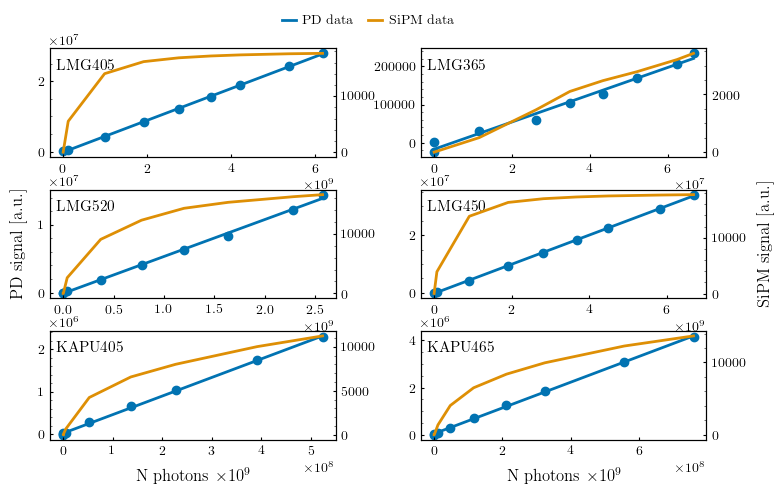

In [45]:
fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)))

for i, ax in enumerate(axes.flat):
    emitter = emitters[i]
    dev_sm = emitter[0]
    dev_name = emitter[1]

    filepath = f'../output/batch2/pocam_{pocam}/hem_{hem}/self_monitoring_{T}C.json'

    with open(filepath, 'r') as f:
        data = json.load(f)


    ax.scatter(data[dev_name]['N_photons_pd'], data[dev_name]['val_adcA'], color = 'C0' )
    y = np.array(data[dev_name]['N_photons_pd'])*data[dev_name]['adcA_slope'] + data[dev_name]['adcA_intercept']
    ax.plot(data[dev_name]['N_photons_pd'], y , color = 'C0' )
    ax.text(0.02,0.8, dev_name, transform=ax.transAxes, size = 11)
    if i == 4 or i == 5:
        ax.set_xlabel(r"N photons $\times 10^9$")
    if i ==2:
        ax.set_ylabel("PD signal [a.u.]")

    # #sipm data
    # mask = np.isin(data_dict[dev_sm]['sipm_data']['tdc2']['flasher_pwm'], pwm)
    ax1 = ax.twinx()
    ax1.plot(data[dev_name]['N_photons_pd'], data[dev_name]['val_tdc2'], color = 'C1' )
    if i ==3:
        ax1.set_ylabel("SiPM signal [a.u.]")

plt.subplots_adjust(hspace=0.3, wspace=0.3)

# legend with manual handles, centered on top
from matplotlib.lines import Line2D
handles = [
    Line2D([0], [0], color='C0', label='PD data'),
    Line2D([0], [0], color='C1', label='SiPM data'),
]
fig.legend(handles=handles, loc='upper center', ncol=2,
           bbox_to_anchor=(0.5, 0.97), frameon=False, columnspacing=1)

plt.savefig(f'../make_plots/plots/png/self_monitoring_hem{hem}_T{T}C.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../make_plots/plots/pdf/self_monitoring_hem{hem}_T{T}C.pdf', dpi=300, bbox_inches='tight')


In [33]:
path_test_sm = f'../output/batch2/pocam_*/hem_*/self_monitoring_{T}C.json'

In [47]:
slopes = {}
dyn_ranges = {}
for T in [-40, -30, -20,-10, 0, 25]:
    slopes[f'{T}C'] = {}
    dyn_ranges[f'{T}C'] = {}
    for emitter in ['LMG405', 'LMG365', 'LMG520', 'LMG450', 'KAPU405', 'KAPU465']:
        slopes[f'{T}C'][emitter] = []
        dyn_ranges[f'{T}C'][emitter] = []
    path_test_sm = f'../output/batch2/pocam_*/hem_*/self_monitoring_{T}C.json'
    filelist = glob.glob(path_test_sm)
    print(len(filelist))
    for f in filelist:
            with open(f, 'r') as file:
                data = json.load(file)
            for emitter in ['LMG405', 'LMG365', 'LMG520', 'LMG450', 'KAPU405', 'KAPU465']:
                slopes[f'{T}C'][emitter].append(data[emitter]['adcA_slope'])
                try:
                    dyn_ranges[f'{T}C'][emitter].append(data[emitter]['tdc2_max-min'])
                except:
                    dyn_ranges[f'{T}C'][emitter].append(np.nan) 
            
            
                

40
40
40
40
40
19


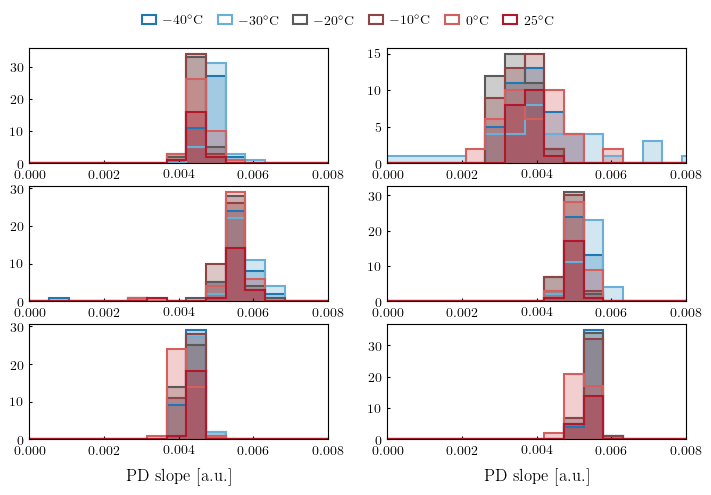

In [35]:
colors = [
    '#1f78b4',  # deep blue       → -40°C
    '#6aafd6',  # light blue      → -25°C
    '#5a5a5a',  # dark grey       → -10°C
    '#8c4444',  # dark muted red  →   5°C  (transition through grey keeps this dark)
    '#d45f5f',  # medium red      →  15°C
    '#b2182b',  # deep red        →  25°C
]

fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)))

for i, ax in enumerate(axes.flat):
    emitter = emitters[i]
    dev_sm = emitter[0]
    dev_name = emitter[1]
    bins = np.linspace(0, 0.01, 20)
    for j, T in enumerate([-40, -30, -20,-10, 0, 25]):
        ax.hist(slopes[f'{T}C'][dev_name], bins=bins, color = colors[j], histtype = 'step', label = f'${T}^\circ$C', linewidth = 1.5)
        ax.hist(slopes[f'{T}C'][dev_name], bins=bins, color = colors[j], alpha=0.3)

    ax.set_xlim(0,0.008)

    if i == 0:
        ax.legend(bbox_to_anchor=(1.8, 1.4), ncol=6, frameon=False, columnspacing=1, fontsize=10)

    if i == 4 or i == 5:
        ax.set_xlabel("PD slope [a.u.]")


plt.savefig(f'../make_plots/plots/png/self_monitoring_total.png', dpi=300, bbox_inches='tight')
plt.savefig(f'../make_plots/plots/pdf/self_monitoring_total.pdf', dpi=300, bbox_inches='tight')


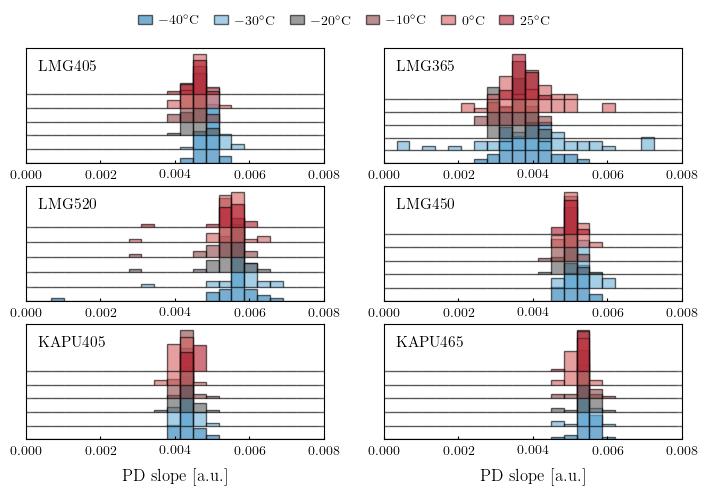

In [36]:
colors = [
    '#1f78b4',  # deep blue       → -40°C
    '#6aafd6',  # light blue      → -25°C
    '#5a5a5a',  # dark grey       → -10°C
    '#8c4444',  # dark muted red  →   5°C
    '#d45f5f',  # medium red      →  15°C
    '#b2182b',  # deep red        →  25°C
]

fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)))

temperatures = [-40, -30, -20, -10, 0, 25]
bins = np.linspace(0, 0.01, 30)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

for i, ax in enumerate(axes.flat):
    emitter = emitters[i]
    dev_sm = emitter[0]
    dev_name = emitter[1]

    # compute all histograms first to set the offset step
    counts_list = []
    for T in temperatures:
        counts, _ = np.histogram(slopes[f'{T}C'][dev_name], bins=bins)
        counts_list.append(counts)

    # small step relative to peak height → partial overlap, not full stacking
    y_step = 0.2 * max(c.max() for c in counts_list)

    for j, (T, counts) in enumerate(zip(temperatures, counts_list)):
        offset = j * y_step  # coldest at bottom, warmest on top
        color = colors[j]

        ax.bar(bin_centers, counts, width=bin_width, bottom=offset,
               color=color, alpha=0.6, edgecolor='k', linewidth=1,
               zorder=j, label=f'${T}^\\circ$C')
        ax.axhline(offset, color='k', lw=0.4, alpha=0.3,
                   xmin=0.02, xmax=0.98, zorder=0)

    ax.set_xlim(0, 0.008)
    ax.set_yticks([])
    ax.text(0.04,0.8, dev_name, transform=ax.transAxes, size = 11)
    if i == 0:
        ax.legend(bbox_to_anchor=(1.8, 1.4), ncol=6, frameon=False, columnspacing=1, fontsize=10)

    if i == 4 or i == 5:
        ax.set_xlabel("PD slope [a.u.]")

plt.savefig('../make_plots/plots/png/self_monitoring_total_PD.png', dpi=300, bbox_inches='tight')
plt.savefig('../make_plots/plots/pdf/self_monitoring_total_PD.pdf', dpi=300, bbox_inches='tight')

In [ ]:
colors = [
    '#1f78b4',  # deep blue       → -40°C
    '#6aafd6',  # light blue      → -25°C
    '#5a5a5a',  # dark grey       → -10°C
    '#8c4444',  # dark muted red  →   5°C
    '#d45f5f',  # medium red      →  15°C
    '#b2182b',  # deep red        →  25°C
]

fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1.2, ratio=0.4, subplots=(3, 2)))

temperatures = [-40, -30, -20, -10, 0, 25]
bins = np.linspace(0, 0.01, 30)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_width = bins[1] - bins[0]

for i, ax in enumerate(axes.flat):
    emitter = emitters[i]
    dev_sm = emitter[0]
    dev_name = emitter[1]

    # compute all histograms first to set the offset step
    counts_list = []
    for T in temperatures:
        counts, _ = np.histogram(slopes[f'{T}C'][dev_name], bins=bins)
        counts_list.append(counts)

    # small step relative to peak height → partial overlap, not full stacking
    y_step = 0.2 * max(c.max() for c in counts_list)

    for j, (T, counts) in enumerate(zip(temperatures, counts_list)):
        offset = j * y_step  # coldest at bottom, warmest on top
        color = colors[j]

        ax.bar(bin_centers, counts, width=bin_width, bottom=offset,
               color=color, alpha=0.6, edgecolor='k', linewidth=1,
               zorder=j, label=f'${T}^\\circ$C')
        ax.axhline(offset, color='k', lw=0.4, alpha=0.3,
                   xmin=0.02, xmax=0.98, zorder=0)

    ax.set_xlim(0, 0.008)
    ax.set_yticks([])
    ax.text(0.04,0.8, dev_name, transform=ax.transAxes, size = 11)
    if i == 0:
        ax.legend(bbox_to_anchor=(1.8, 1.4), ncol=6, frameon=False, columnspacing=1, fontsize=10)

    if i == 4 or i == 5:
        ax.set_xlabel("PD slope [a.u.]")

plt.savefig('../make_plots/plots/png/self_monitoring_total_SiPM.png', dpi=300, bbox_inches='tight')
plt.savefig('../make_plots/plots/pdf/self_monitoring_total_SiPM.pdf', dpi=300, bbox_inches='tight')